In [3]:
#import the packages
import numpy as np
from scipy import stats
import math

#For visualiing distributions - optional
import seaborn as sns
import matplotlib.pyplot as plt

#sample data listed above
sample = np.array([122.09, 100.64, 125.77, 120.32, 118.25,  96.47, 111.4 , 80.66,
       110.77, 111.14, 102.9 , 114.54,  88.09,  98.59,  87.07, 110.43,
       101.9 , 123.89,  97.03, 116.23, 108.3 , 112.82, 119.57, 131.38,
       128.39])


In [2]:
#population mean()
#(known from past data)
mu = 100
mu

100

In [4]:
x_bar = sample.mean()
x_bar

np.float64(109.5456)

In [5]:
sigma = np.std(sample,ddof=1)
sigma

np.float64(13.338774643871902)

In [6]:
n = len(sample)
n

25

In [7]:
#Degrees of freedom
df =n-1
df

24

In [8]:
#Diff between sample mean and population mean
diff = x_bar - mu
diff

np.float64(9.545599999999993)

In [11]:
#print the findings
print(f"""
The sample contains {n} observations, having a mean of {x_bar} 
and a standard deviation (sigma) of {round (sigma,3)}, with {df} degrees bof freedom.

The difference between sample and population means is  {round(diff, 2)}
""")


The sample contains 25 observations, having a mean of 109.5456 
and a standard deviation (sigma) of 13.339, with 24 degrees bof freedom.

The difference between sample and population means is  9.55



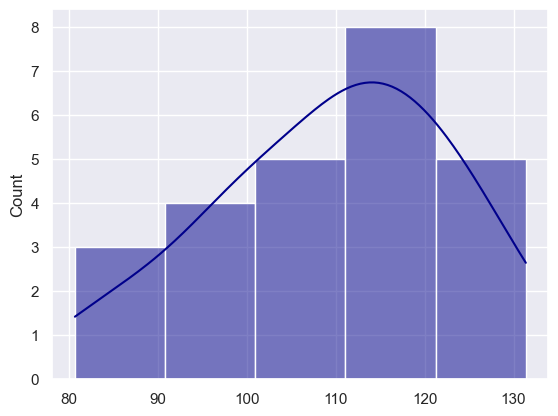

In [12]:
sns.set(color_codes=True)
sns.histplot(sample, kde=True, bins=5, color='darkblue');

In [13]:
t = (x_bar-mu)/(sigma/np.sqrt(n))
t

np.float64(3.578139767278185)

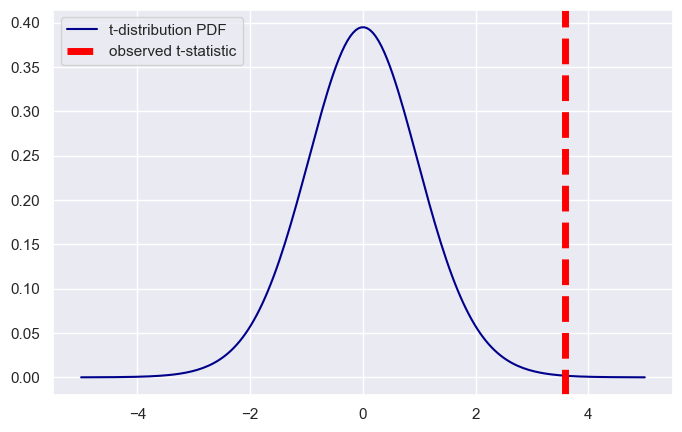

In [14]:
# Set up figure and axes
fig, ax = plt.subplots(figsize=(8,5))

# Generate data for plotting the PDF
# (1) generate points on the x axis between -5 and 5:
x = np.linspace(-5, 5, 200)
# (2) use stats.t.pdf to get values on the probability density
# function for the t-distribution
y = stats.t.pdf(x, df, 0, 1)

# Plot the PDF as a line graph
ax.plot(x, y, color='darkblue', label="t-distribution PDF")

# Plot a vertical line for our measured difference in sales t-statistic
ax.axvline(t, color='red', linestyle='--', lw=5,label='observed t-statistic')

ax.legend();

In [19]:
t_crit = stats.t.ppf(1-0.05, df=24)
t_crit

np.float64(1.710882079909428)

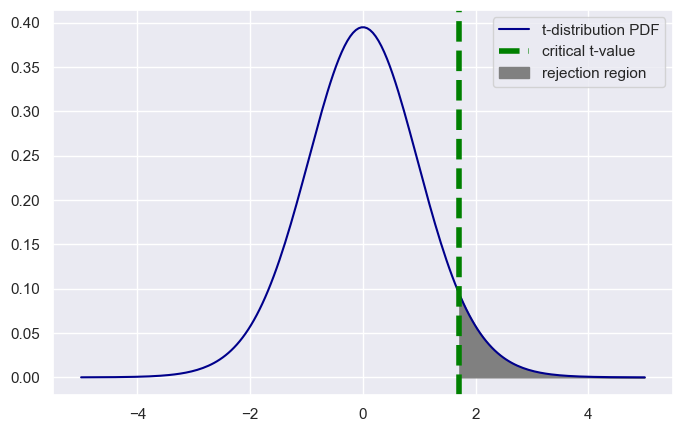

In [20]:
# Set up figure and axes
fig, ax = plt.subplots(figsize=(8,5))

# Plot the PDF as a line graph
# (x and y were created in previous plotting code)
ax.plot(x, y, color='darkblue', label="t-distribution PDF")

# Plot a vertical line for our critical t-value
ax.axvline(t_crit,color='green',linestyle='--',lw=4,label='critical t-value')

# Fill area under line graph where x value is creater than critical t
ax.fill_betweenx(y,x,t_crit,where=x > t_crit,color="gray",label="rejection region")

ax.legend();

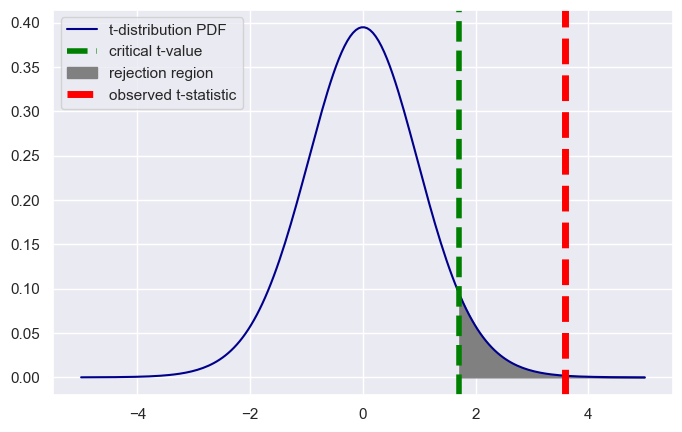

In [21]:
# Set up figure and axes
fig, ax = plt.subplots(figsize=(8,5))

# Plot the PDF as a line graph
# (x and y were created in previous plotting code)
ax.plot(x, y, color='darkblue', label="t-distribution PDF")

# Plot a vertical line for our critical t-value
ax.axvline(t_crit,color='green',linestyle='--',lw=4,label='critical t-value')

# Fill area under line graph where x value is creater than critical t
ax.fill_betweenx(y,x,t_crit,where=x > t_crit,color="gray",label="rejection region")

# Plot a vertical line for our measured difference in sales t-statistic
ax.axvline(t, color='red', linestyle='--', lw=5,label='observed t-statistic')

ax.legend();

In [22]:
p_value = stats.t.sf(t, df=24)
p_value

np.float64(0.0007589472707557046)

In [23]:
results = stats.ttest_1samp(
    a=sample,   # the entire array-like sample
    popmean=100 # the mean you are testing the sample against
)

results

TtestResult(statistic=np.float64(3.578139767278185), pvalue=np.float64(0.0015178945415114092), df=np.int64(24))

In [24]:
print(t)
print(results.statistic)

3.578139767278185
3.578139767278185


In [25]:
alpha = 0.05

t_crit = stats.t.ppf(1 - alpha, df=len(sample)-1)

if results.statistic > t_crit:
    print("Null hypothesis rejected.")
    print("The increase in sales performance is statistically significant at the", alpha, "level.")
else:
    print("Failed to reject the null hypothesis.")
    print("The increase in sales performance is not statistically significant at the", alpha, "level.")

Null hypothesis rejected.
The increase in sales performance is statistically significant at the 0.05 level.


In [26]:
print(p_value)
print(results.pvalue)

0.0007589472707557046
0.0015178945415114092


In [27]:
print(p_value)
print(results.pvalue / 2)

0.0007589472707557046
0.0007589472707557046


In [28]:
if (results.pvalue / 2) < alpha:
    print("Null hypothesis rejected.")
    print("The increase in sales performance is statistically significant at the", alpha, "level.")
else:
    print("Failed to reject the null hypothesis.")
    print("The increase in sales performance is not statistically significant at the", alpha, "level.")

Null hypothesis rejected.
The increase in sales performance is statistically significant at the 0.05 level.


In [29]:
print("results.statistic:", results.statistic)
print("results[0]:       ", results[0])
print("results.pvalue:   ", results.pvalue)
print("results[1]:       ", results[1])

results.statistic: 3.578139767278185
results[0]:        3.578139767278185
results.pvalue:    0.0015178945415114092
results[1]:        0.0015178945415114092
